Import Required Libraries

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset & Data Assessment

In [3]:
# Load Dataset
cars = pd.read_csv("Car_prices.csv")

# Display first 5 rows
display(cars.head())

# Dataset shape
print("Dataset Shape:", cars.shape)

# Dataset Information
print("\nDataset Information")
cars.info()

# Statistical Summary
print("\nStatistical Summary")
display(cars.describe())

# Missing Values
print("\nMissing Values")
print(cars.isnull().sum())

# Duplicate Records
print("\nDuplicate Records:", cars.duplicated().sum())

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Dataset Shape: (301, 9)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB

Statistical Summary


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000



Missing Values
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Duplicate Records: 2


Data Cleaning & Feature Engineering

In [4]:
# Create Car Age Feature
current_year = 2025
cars["Car_Age"] = current_year - cars["Year"]

# Drop unnecessary columns
cars.drop(["Car_Name", "Year"], axis=1, inplace=True)

encoder = LabelEncoder()
cars["Fuel_Type"] = encoder.fit_transform(cars["Fuel_Type"])
cars["Selling_type"] = encoder.fit_transform(cars["Selling_type"])
cars["Transmission"] = encoder.fit_transform(cars["Transmission"])

display(cars.head())

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,11
1,4.75,9.54,43000,1,0,1,0,12
2,7.25,9.85,6900,2,0,1,0,8
3,2.85,4.15,5200,2,0,1,0,14
4,4.60,6.87,42450,1,0,1,0,11


Exploratory Data Analysis (EDA)

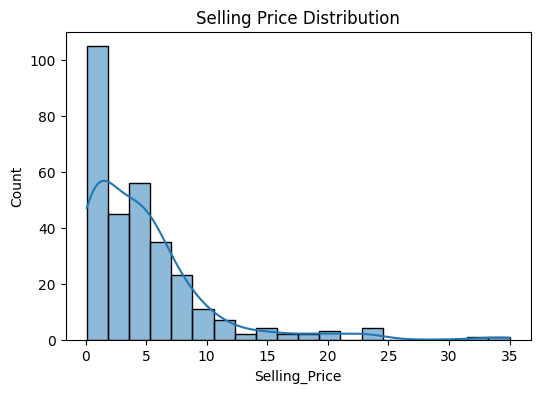

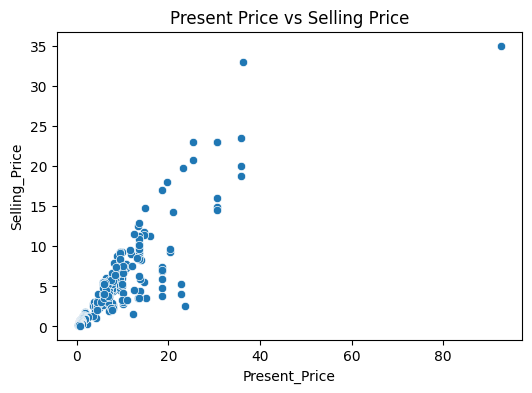

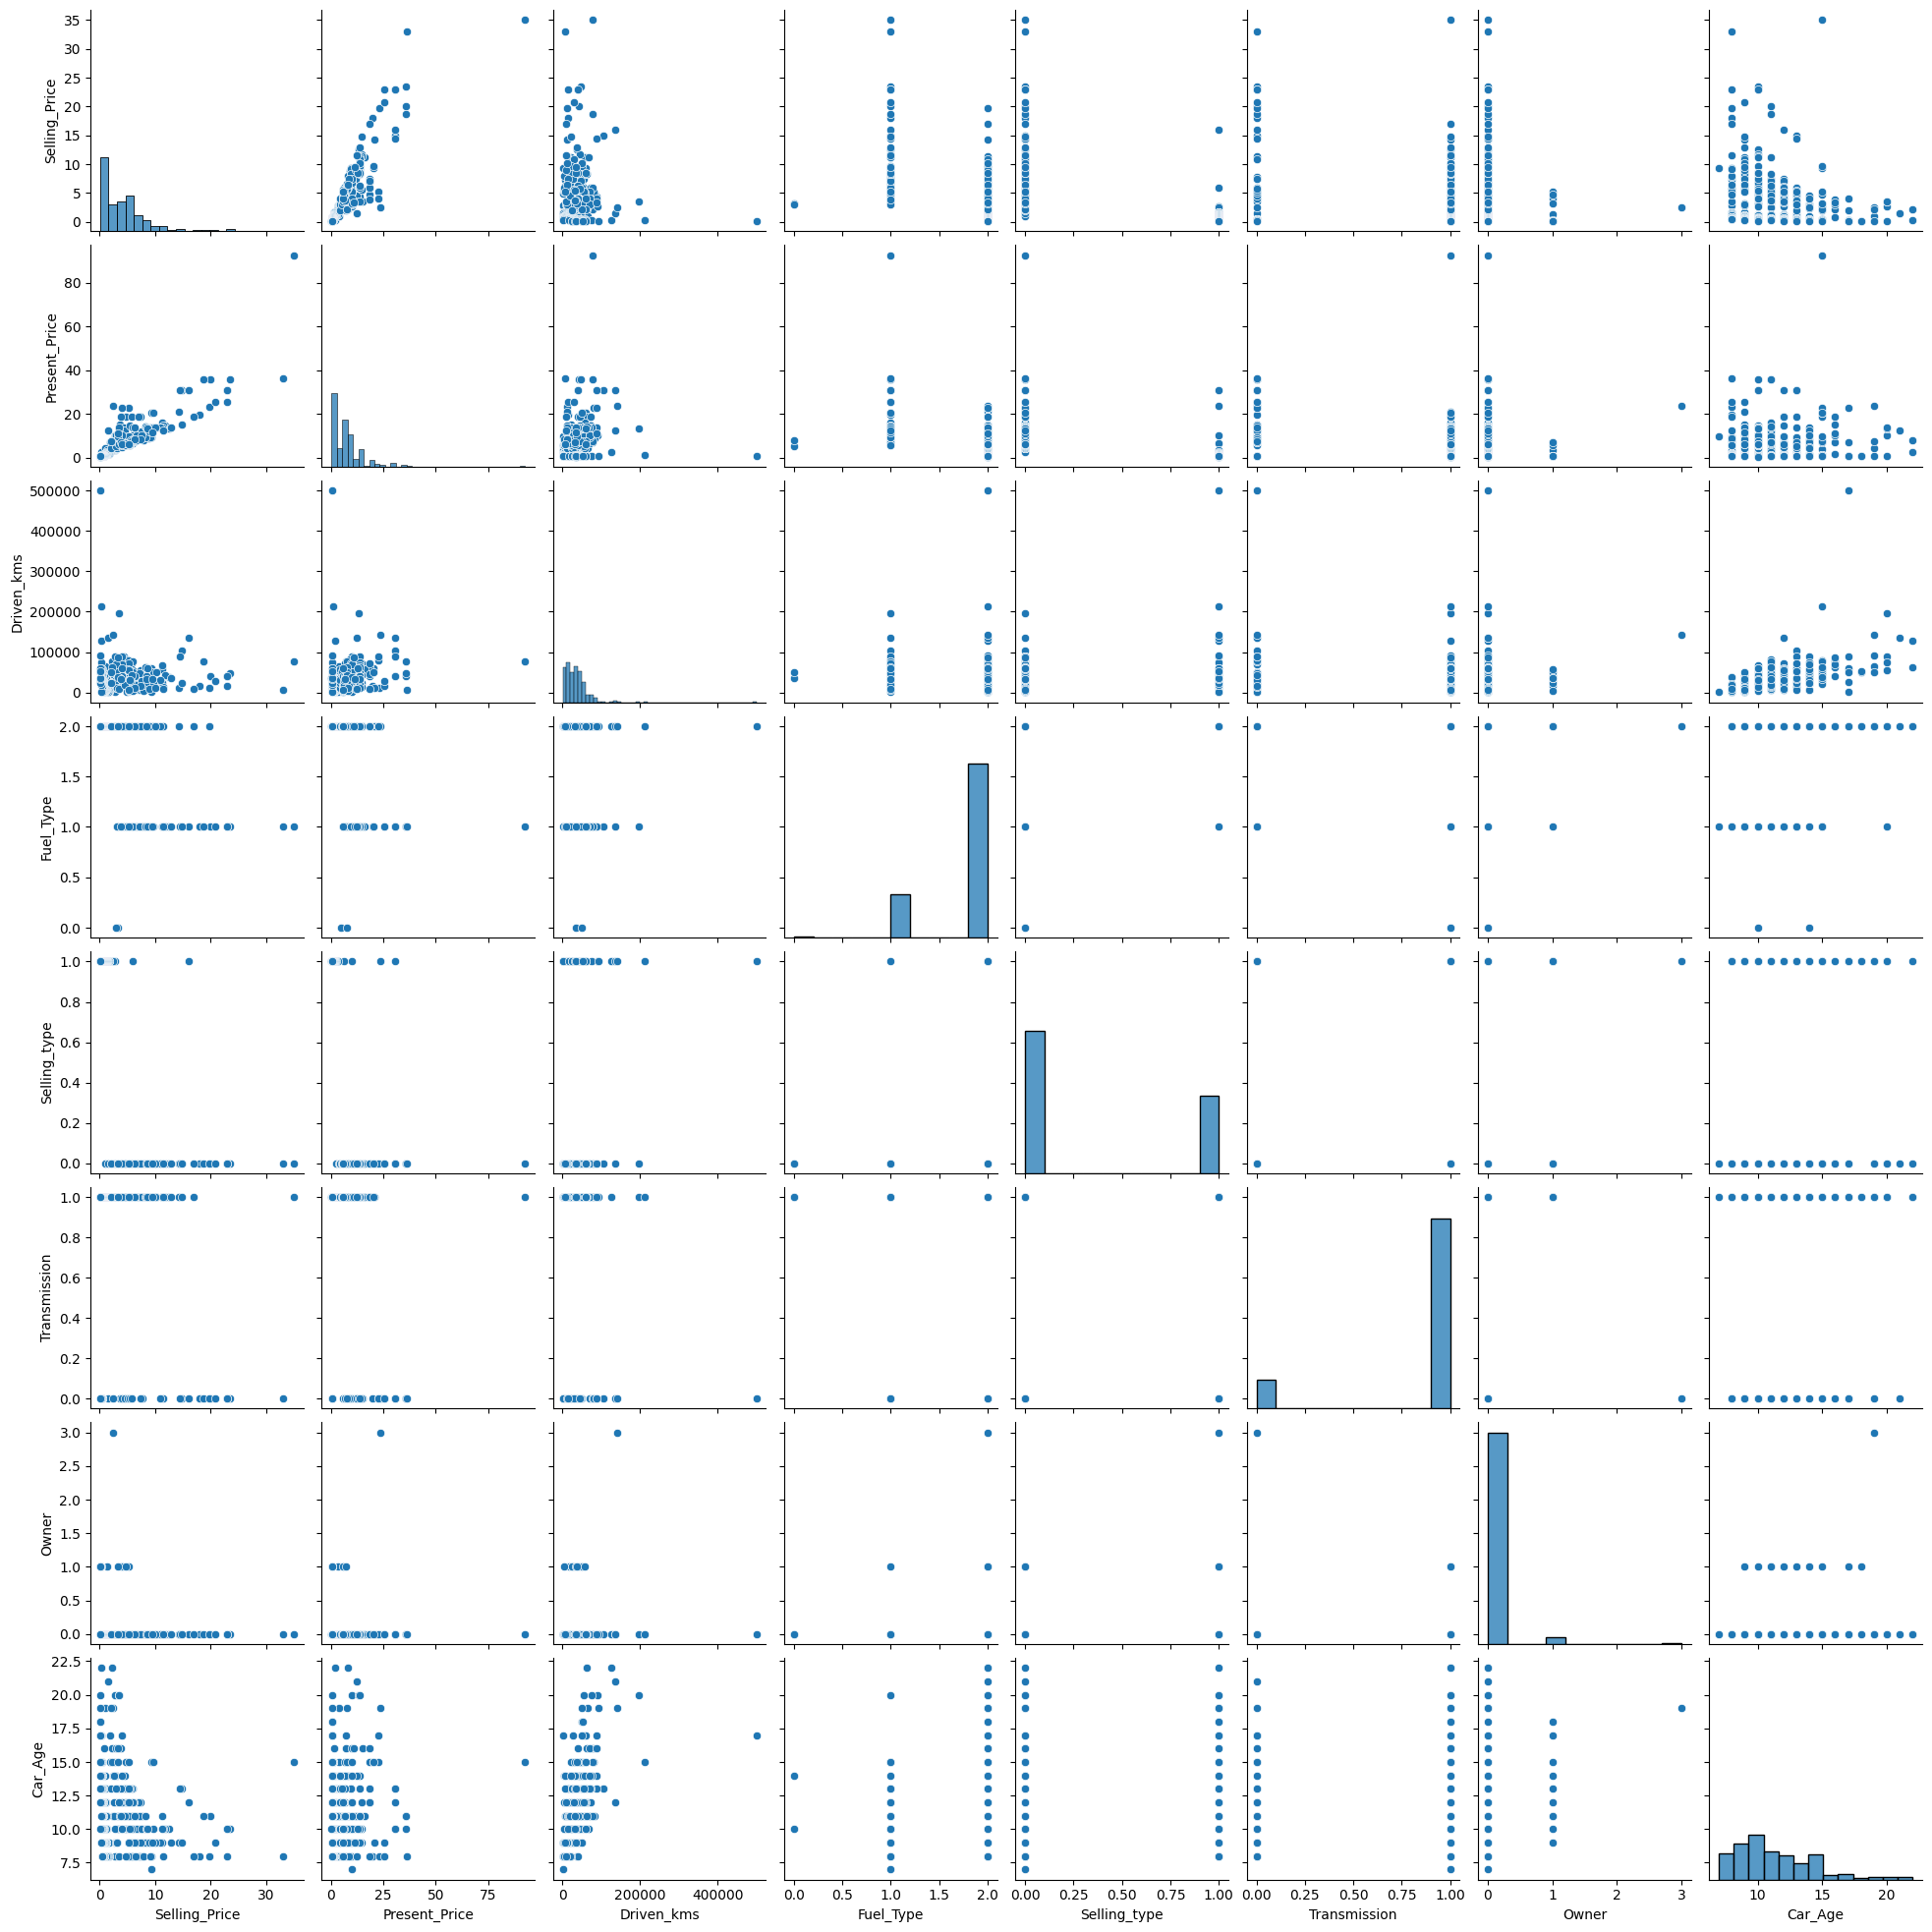

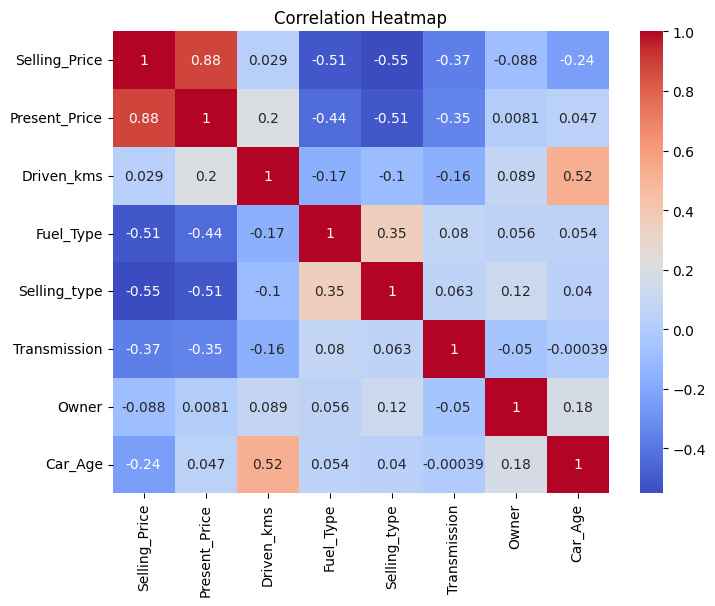

In [5]:
# Selling Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(cars["Selling_Price"], bins=20, kde=True)
plt.title("Selling Price Distribution")
plt.show()

# Present Price vs Selling Price
plt.figure(figsize=(6,4))
sns.scatterplot(x="Present_Price", y="Selling_Price", data=cars)
plt.title("Present Price vs Selling Price")
plt.show()

sns.pairplot(cars)
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cars.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Data Preparation

In [6]:
# Features
X = cars.drop("Selling_Price", axis=1)

# Target
y = cars["Selling_Price"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (240, 7)
Testing Shape: (61, 7)


Model Training & Prediction

In [7]:
# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Model Trained Successfully!")

Model Trained Successfully!


Model Evaluation

Mean Absolute Error: 1.2219323621753853
Mean Squared Error: 3.5315798889686385
Root Mean Squared Error: 1.8792498207978199
R² Score: 0.8466902419663827


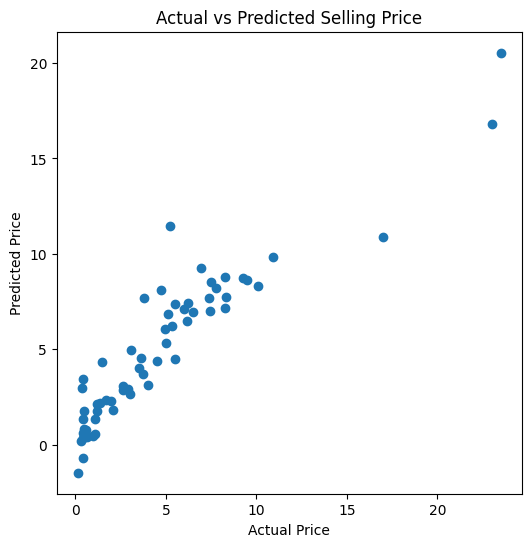

In [8]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

Predict Price of a New Car

In [9]:
# Example New Car

new_car = pd.DataFrame({
    "Present_Price":[8.5],
    "Driven_kms":[35000],
    "Fuel_Type":[2],        # Petrol
    "Selling_type":[0],     # Dealer
    "Transmission":[1],     # Manual
    "Owner":[0],
    "Car_Age":[5]
})

predicted_price = model.predict(new_car)

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 7.376541100247273
